In [125]:
import os
import sys
current_dir = os.getcwd()
root_path = os.path.abspath(os.path.join(current_dir, '..', '..'))
if root_path not in sys.path:
    sys.path.append(root_path)
import torch
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import torch.nn as nn
import numpy as np
import pickle
import pandas as pd
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import math
import scipy.special
import random as rd
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torchvision.models as models
from torchvision.models import VGG16_Weights
from tqdm import tqdm
import torch.optim.lr_scheduler as lr_scheduler
from python_scripts.sgp_utils import *
from python_scripts.plotting import *
from scipy.special import gammaln
import warnings
warnings.filterwarnings("ignore")
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 100

print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: True
GPU Name: NVIDIA GeForce RTX 4060


#### Choose the dataset you want to use :
* must be data the model did not see at training
* first column : __y_true__ $\in \{0,1\}$ are the samples labels  
* second column : __y_pred__ are the predicted class of samples ($\in \{0,1\}$ too)
* third column : __kappa_f__ is confidence function for each sample, $\in \mathbb{R}$

In [126]:
sgp_df_SR = pickle.load(open('sgp_set_cnn','rb')) 
print(sgp_df_SR.shape)
print('Propotion of 1s: ', np.round(sgp_df_SR.y_true.sum()/sgp_df_SR.shape[0],2))
sgp_df_SR.head() 

(6788, 3)
Propotion of 1s:  0.33


,y_true,y_pred,kappa
0,0.0,0.0,0.985617
1,1.0,1.0,0.899486
2,1.0,1.0,0.952112
3,0.0,0.0,0.994921
4,0.0,0.0,0.978682


In [127]:
sgp_df_MCD = pickle.load(open('sgp_set_cnn_MCD','rb')) 
print(sgp_df_MCD.shape)
print('Propotion of 1s: ', np.round(sgp_df_MCD.y_true.sum()/sgp_df_MCD.shape[0],2))
sgp_df_MCD.head()

(6788, 3)
Propotion of 1s:  0.33


,y_true,y_pred,kappa
0,0.0,0.0,-0.000600
1,1.0,1.0,-0.003494
2,1.0,1.0,-0.001536
3,0.0,0.0,-0.000046
4,0.0,0.0,-0.001196


In [ ]:
delta = 0.005 # = 1 - probability that the metric be controlled by the bound
greedy_search_steps_num = 50 # number of theta confidence thresholds considered during the greedy search. For Softmax Response it splits [0.5, 1] into greedy_search_steps_num intervals
num_targets = 100 # number of targets r* to consider when drawing metric/coverage of metric/theta curves

In [129]:
train_set_SR = sgp_df_SR.iloc[:3*int(len(sgp_df_SR)/4)] # set that will be used to derive the bounds
train_set_SR = train_set_SR.sort_values('kappa', ascending=True).reset_index(drop=True).copy() # we sort by confidence function, as specified in Algorithms 1-2
test_set_SR = sgp_df_SR.iloc[3*int(len(sgp_df_SR)/4):] # set that will be used to test the bounds computed on train_set

# idem, with Monte Carlo Dropout minus variance as confidence function
train_set_MCD = sgp_df_MCD.iloc[:3*int(len(sgp_df_MCD)/4)]
train_set_MCD = train_set_MCD.sort_values('kappa', ascending=True).reset_index(drop=True).copy()
test_set_MCD = sgp_df_MCD.iloc[3*int(len(sgp_df_MCD)/4):]

Plot lines configuration 

In [130]:
# Softmax Response (SR) by confidence threshold theta
lines_list_1_SR = [{'kappa':'SR','name':'Target', 'colname':'metric_target','x_axis':'theta_star','x_axis_name':r'$\theta$','colour':'#d51414','style':'-'},
                   {'kappa':'SR','name':'Guaranteed', 'colname':'metric_bound','x_axis':'theta_star','x_axis_name':r'$\theta$','colour':'#1d3ae2','style':'--'},
                   {'kappa':'SR','name':'On train set', 'colname':'train_metric','x_axis':'theta_star','x_axis_name':r'$\theta$','colour':'#8F7A1C','style':'--'},
                   {'kappa':'SR','name':'On test set', 'colname':'test_metric','x_axis':'theta_star','x_axis_name':r'$\theta$','colour':'#0f770a','style':'-'}]
# Softmax Response (SR) by coverage
lines_list_2_SR = [{'kappa':'SR','name':'Target', 'colname':'metric_target','x_axis':'test_coverage','x_axis_name':'Coverage','colour':'#d51414','style':'-'},
                   {'kappa':'SR','name':'Guaranteed', 'colname':'metric_bound','x_axis':'test_coverage','x_axis_name':'Coverage','colour':'#1d3ae2','style':'--'},
                   {'kappa':'SR','name':'On train set', 'colname':'train_metric','x_axis':'test_coverage','x_axis_name':'Coverage','colour':'#8F7A1C','style':'--'},
                   {'kappa':'SR','name':'On test set', 'colname':'test_metric','x_axis':'test_coverage','x_axis_name':'Coverage','colour':'#0f770a','style':'-'}]
# MCD minus variance by confidence threshold theta
lines_list_1_MCD = [{'kappa':'MCD','name':'Target', 'colname':'metric_target','x_axis':'theta_star','x_axis_name':r'$\theta$','colour':'#d51414','style':'-'},
                    {'kappa':'MCD','name':'Guaranteed', 'colname':'metric_bound','x_axis':'theta_star','x_axis_name':r'$\theta$','colour':'#1d3ae2','style':'--'},
                    {'kappa':'MCD','name':'On train set', 'colname':'train_metric','x_axis':'theta_star','x_axis_name':r'$\theta$','colour':'#8F7A1C','style':'--'},
                    {'kappa':'MCD','name':'On test set', 'colname':'test_metric','x_axis':'theta_star','x_axis_name':r'$\theta$','colour':'#0f770a','style':'-'}]
# MCD minus variance by coverage
lines_list_2_MCD = [{'kappa':'MCD','name':'Target', 'colname':'metric_target','x_axis':'test_coverage','x_axis_name':'Coverage','colour':'#d51414','style':'-'},
                    {'kappa':'MCD','name':'Guaranteed', 'colname':'metric_bound','x_axis':'test_coverage','x_axis_name':'Coverage','colour':'#1d3ae2','style':'--'},
                    {'kappa':'MCD','name':'On train set', 'colname':'train_metric','x_axis':'test_coverage','x_axis_name':'Coverage','colour':'#8F7A1C','style':'--'},
                    {'kappa':'MCD','name':'On test set', 'colname':'test_metric','x_axis':'test_coverage','x_axis_name':'Coverage','colour':'#0f770a','style':'-'}]
# SR and MCD on same plot, by coverage
lines_list_2 = [{'kappa':'SR','name':'Guaranteed (SR)', 'colname':'metric_bound','x_axis':'test_coverage','x_axis_name':'Coverage','colour':"#053379",'style':'-'},
                {'kappa':'SR','name':'On test set (SR)', 'colname':'test_metric','x_axis':'test_coverage','x_axis_name':'Coverage','colour':'#053379','style':'--'},
                {'kappa':'MCD','name':'Guaranteed (MCD)', 'colname':'metric_bound','x_axis':'test_coverage','x_axis_name':'Coverage','colour':"#0f770a",'style':'-'},
                {'kappa':'MCD','name':'On test set (MCD)', 'colname':'test_metric','x_axis':'test_coverage','x_axis_name':'Coverage','colour':'#0f770a','style':'--'}]

## <font color = 'orange'> 1. __Unconditional risks__
Dichotomy search for upper bound

### <font color = 'orange'> 1.1. __0/1 risk__

In [131]:
# we restricted after checking the bounds in joint_control_*.ipynb ; without prior knowledge just search over [0,1] with a higher num_targets
metric_targets = np.linspace(0.02,0.13,num=num_targets)

In [132]:
results_SR = sgp_at_targets(train_set_SR, test_set_SR,
                         delta=delta, metric_targets=metric_targets, mode='dicho')
results_MCD = sgp_at_targets(train_set_MCD, test_set_MCD,
                         delta=delta, metric_targets=metric_targets, mode='dicho')
all_results = {'SR': results_SR,
               'MCD': results_MCD}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

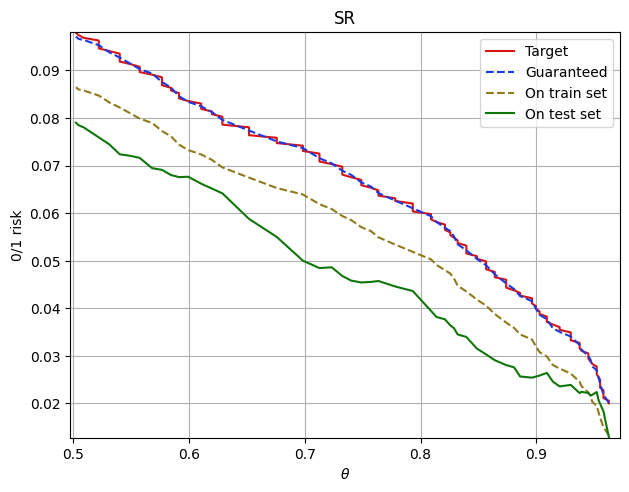

In [133]:
metric_plots(all_results, metric='0/1 risk', 
             lines_list=lines_list_1_SR,
             xlim=[0.99*min(results_SR.theta_star),1.01*max(results_SR.theta_star)], 
             ylim=[0.99*min(min(results_SR.test_metric), min(results_SR.train_metric)), 1.01*max(results_SR.metric_bound)],
             title='SR')

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

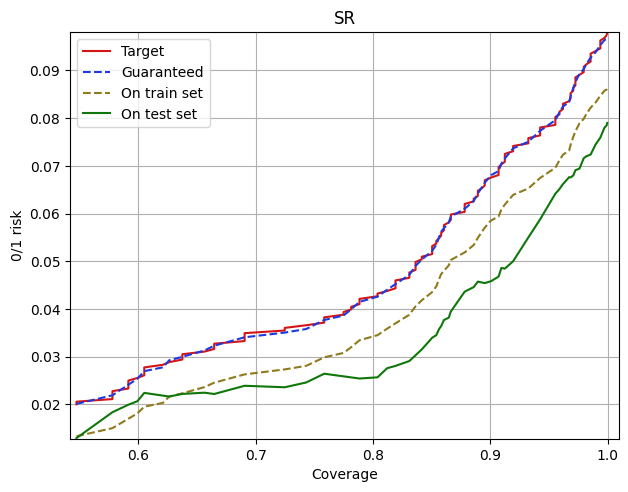

In [134]:
metric_plots(all_results, metric='0/1 risk', 
             lines_list=lines_list_2_SR,
             xlim=[0.99*min(results_SR.test_coverage),1.01*max(results_SR.test_coverage)], 
             ylim=[0.99*min(min(results_SR.test_metric), min(results_SR.train_metric)), 1.01*max(results_SR.metric_bound)],
             title='SR')

Curves w.r.t. $\theta$, using Monte Carlo Dropout (MCD) minus variance as confidence function

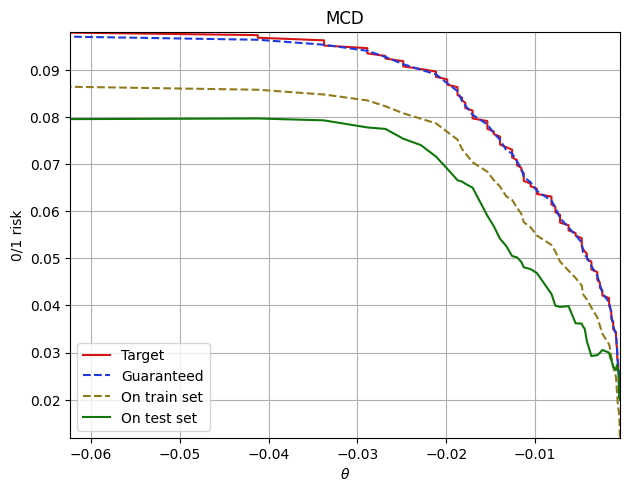

In [135]:
metric_plots(all_results, metric='0/1 risk', 
             lines_list=lines_list_1_MCD,
             xlim=[0.99*min(results_MCD.theta_star),1.01*max(results_MCD.theta_star)], 
             ylim=[0.99*min(min(results_MCD.test_metric), min(results_MCD.train_metric)), 1.01*max(results_MCD.metric_bound)],
             title='MCD')

Curves w.r.t. coverage, using Monte Carlo Dropout (MCD) minus variance as confidence function

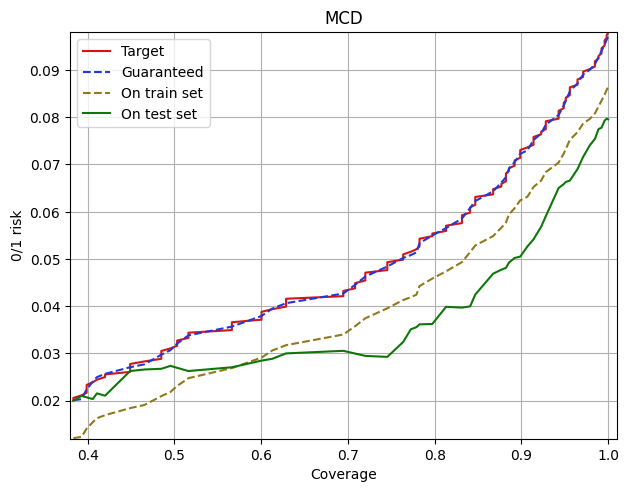

In [136]:
metric_plots(all_results, metric='0/1 risk', 
             lines_list=lines_list_2_MCD,
             xlim=[0.99*min(results_MCD.test_coverage),1.01*max(results_MCD.test_coverage)], 
             ylim=[0.99*min(min(results_MCD.test_metric), min(results_MCD.train_metric)), 1.01*max(results_MCD.metric_bound)],
             title='MCD')

Bounds and test set estimates w.r.t. coverage, SR v. MCD 

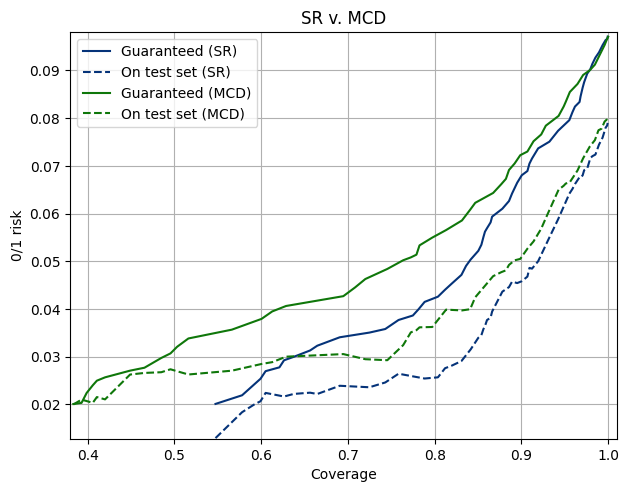

In [137]:
metric_plots(all_results, metric='0/1 risk', 
             lines_list=lines_list_2,
             xlim=[0.99*min(min(results_SR.test_coverage),min(results_MCD.test_coverage)),
                   1.01*max(max(results_MCD.test_coverage),max(results_SR.test_coverage))], 
             ylim=[0.99*min(min(results_MCD.test_metric), min(results_SR.test_metric)), 
                   1.01*max(max(results_MCD.metric_bound),max(results_SR.metric_bound))],
             title='SR v. MCD')

### <font color = 'orange'> 1.2. __FP risk__

In [138]:
metric_targets = np.linspace(0.001,0.12,num=num_targets)

In [139]:
results_SR = sgp_at_targets(train_set_SR, test_set_SR, 
                            delta=delta, metric_targets=metric_targets, 
                            metric='FP', mode='dicho')
results_MCD = sgp_at_targets(train_set_MCD, test_set_MCD, 
                             delta=delta, metric_targets=metric_targets,
                             metric='FP', mode='dicho')
all_results = {'SR': results_SR,
               'MCD': results_MCD}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

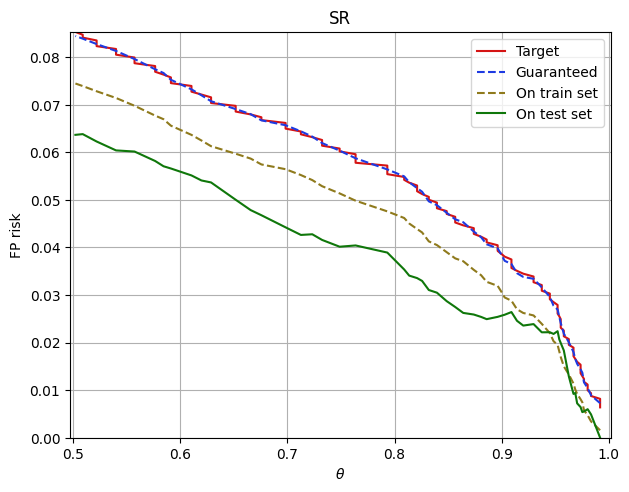

In [140]:
metric_plots(all_results, metric='FP risk', 
             lines_list=lines_list_1_SR,
             xlim=[0.99*min(results_SR.theta_star),1.01*max(results_SR.theta_star)], 
             ylim=[0.99*min(min(results_SR.test_metric), min(results_SR.train_metric)), 1.01*max(results_SR.metric_bound)],
             title='SR')

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

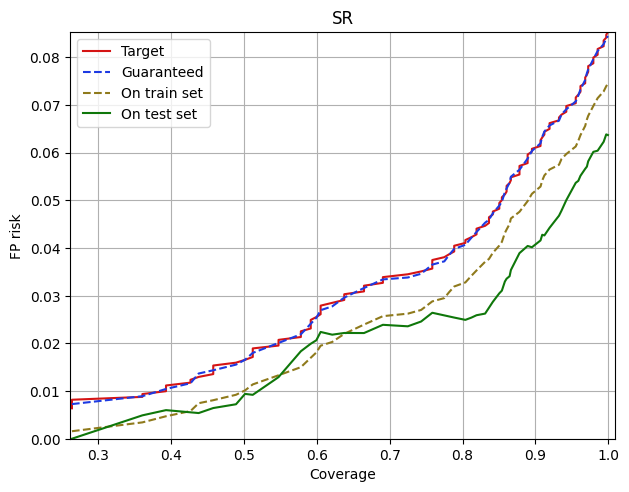

In [141]:
metric_plots(all_results, metric='FP risk', 
             lines_list=lines_list_2_SR,
             xlim=[0.99*min(results_SR.test_coverage),1.01*max(results_SR.test_coverage)], 
             ylim=[0.99*min(min(results_SR.test_metric), min(results_SR.train_metric)), 1.01*max(results_SR.metric_bound)],
             title='SR')

Curves w.r.t. $\theta$, using Monte Carlo Dropout (MCD) minus variance as confidence function

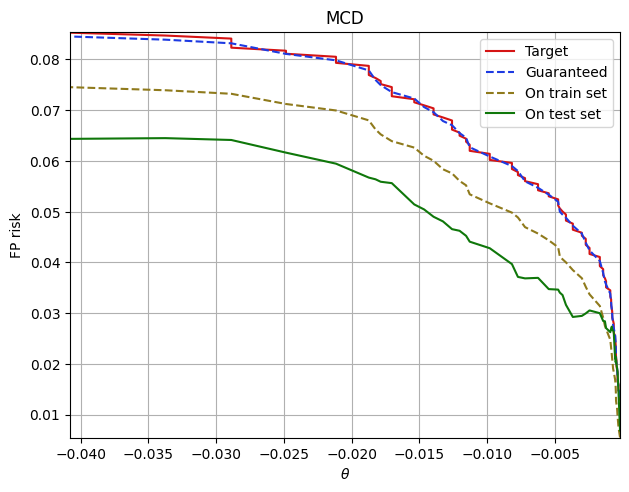

In [142]:
metric_plots(all_results, metric='FP risk', 
             lines_list=lines_list_1_MCD,
             xlim=[0.99*min(results_MCD.theta_star),1.01*max(results_MCD.theta_star)], 
             ylim=[0.99*min(min(results_MCD.test_metric), min(results_MCD.train_metric)), 1.01*max(results_MCD.metric_bound)],
             title='MCD')

Curves w.r.t. coverage, using Monte Carlo Dropout (MCD) minus variance as confidence function

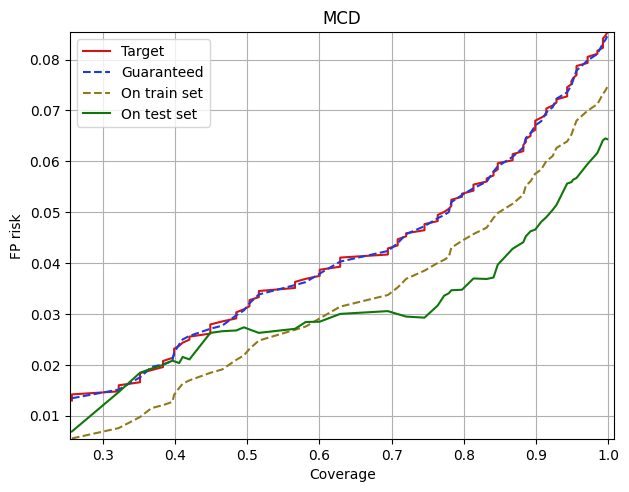

In [143]:
metric_plots(all_results, metric='FP risk', 
             lines_list=lines_list_2_MCD,
             xlim=[0.99*min(results_MCD.test_coverage),1.01*max(results_MCD.test_coverage)], 
             ylim=[0.99*min(min(results_MCD.test_metric), min(results_MCD.train_metric)), 1.01*max(results_MCD.metric_bound)],
             title='MCD')

Bounds and test set estimates w.r.t. coverage, SR v. MCD 

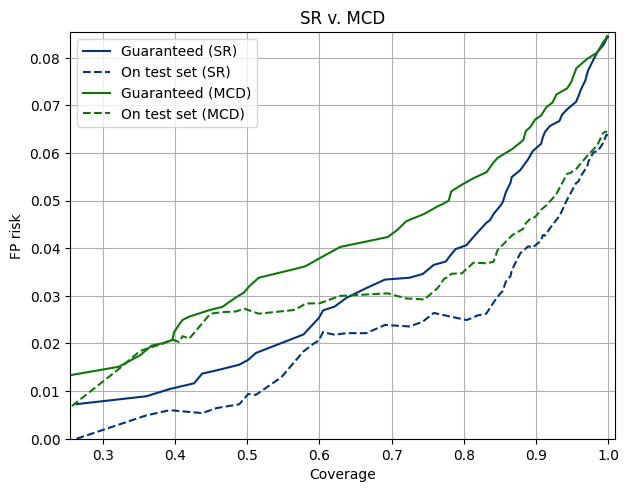

In [144]:
metric_plots(all_results, metric='FP risk', 
             lines_list=lines_list_2,
             xlim=[0.99*min(min(results_SR.test_coverage),min(results_MCD.test_coverage)),
                   1.01*max(max(results_MCD.test_coverage),max(results_SR.test_coverage))], 
             ylim=[0.99*min(min(results_MCD.test_metric), min(results_SR.test_metric)), 
                   1.01*max(max(results_MCD.metric_bound),max(results_SR.metric_bound))],
             title='SR v. MCD')

### <font color = 'orange'> 1.3. __FN risk__

In [145]:
metric_targets = np.linspace(0.0001,0.02,num=num_targets)

In [146]:
results_SR = sgp_at_targets(train_set_SR, test_set_SR, 
                            delta=delta, metric_targets=metric_targets, 
                            metric='FN', mode='dicho')
results_MCD = sgp_at_targets(train_set_MCD, test_set_MCD, 
                             delta=delta, metric_targets=metric_targets,
                             metric='FN', mode='dicho')
all_results = {'SR': results_SR,
               'MCD': results_MCD}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

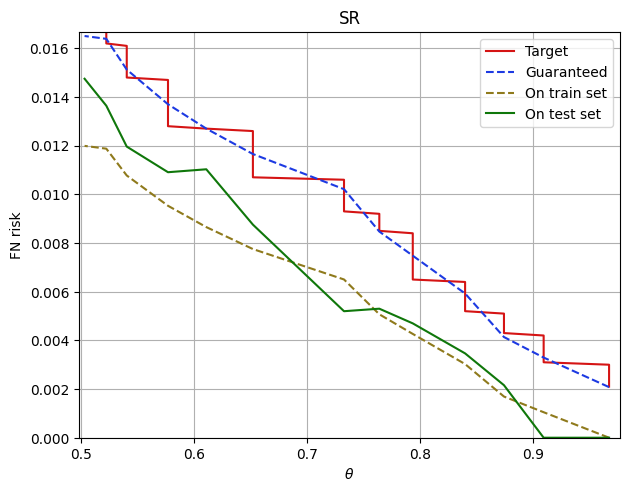

In [147]:
metric_plots(all_results, metric='FN risk', 
             lines_list=lines_list_1_SR,
             xlim=[0.99*min(results_SR.theta_star),1.01*max(results_SR.theta_star)], 
             ylim=[0.99*min(results_SR.test_metric), 1.01*max(results_SR.metric_bound)],
             title='SR')

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

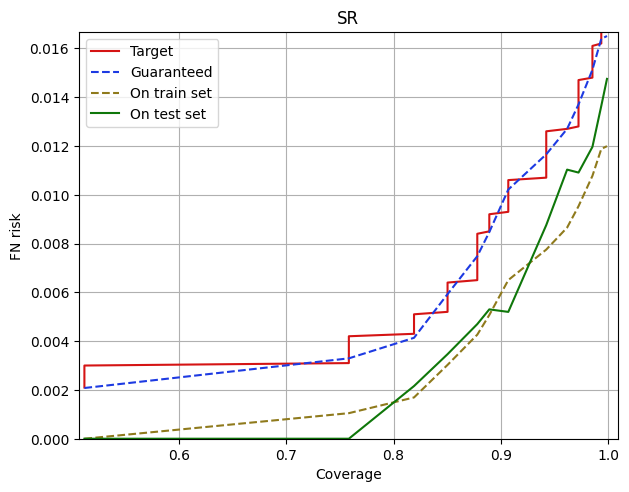

In [148]:
metric_plots(all_results, metric='FN risk', 
             lines_list=lines_list_2_SR,
             xlim=[0.99*min(results_SR.test_coverage),1.01*max(results_SR.test_coverage)], 
             ylim=[0.99*min(results_SR.test_metric), 1.01*max(results_SR.metric_bound)],
             title='SR')

Curves w.r.t. $\theta$, using Monte Carlo Dropout (MCD) minus variance as confidence function

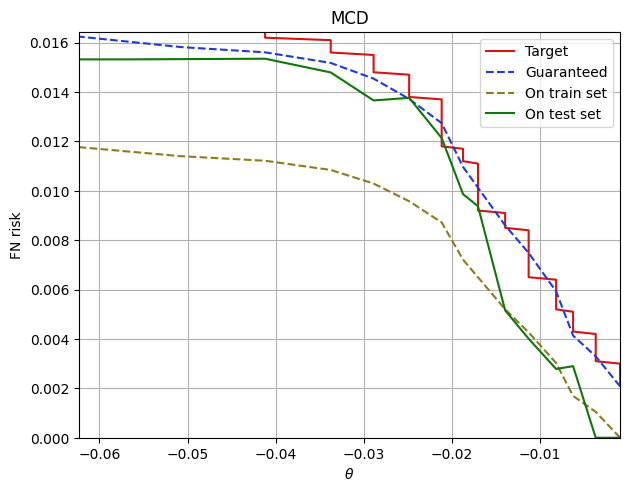

In [149]:
metric_plots(all_results, metric='FN risk', 
             lines_list=lines_list_1_MCD,
             xlim=[0.99*min(results_MCD.theta_star),1.01*max(results_MCD.theta_star)], 
             ylim=[0.99*min(results_MCD.test_metric), 1.01*max(results_MCD.metric_bound)],
             title='MCD')

Curves w.r.t. coverage, using Monte Carlo Dropout (MCD) minus variance as confidence function

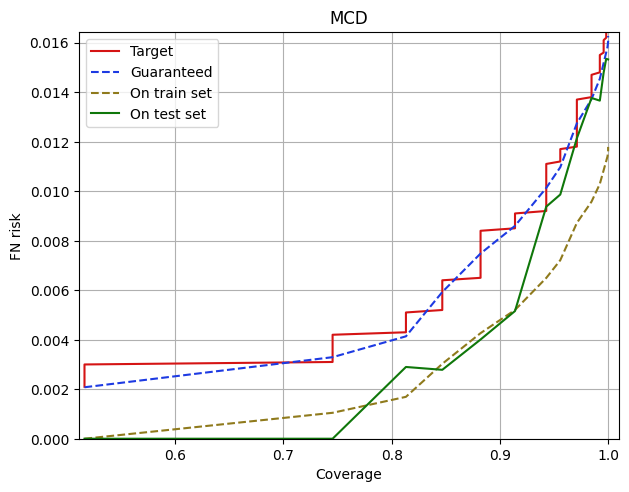

In [150]:
metric_plots(all_results, metric='FN risk', 
             lines_list=lines_list_2_MCD,
             xlim=[0.99*min(results_MCD.test_coverage),1.01*max(results_MCD.test_coverage)], 
             ylim=[0.99*min(results_MCD.test_metric), 1.01*max(results_MCD.metric_bound)],
             title='MCD')

Bounds and test set estimates w.r.t. coverage, SR v. MCD 

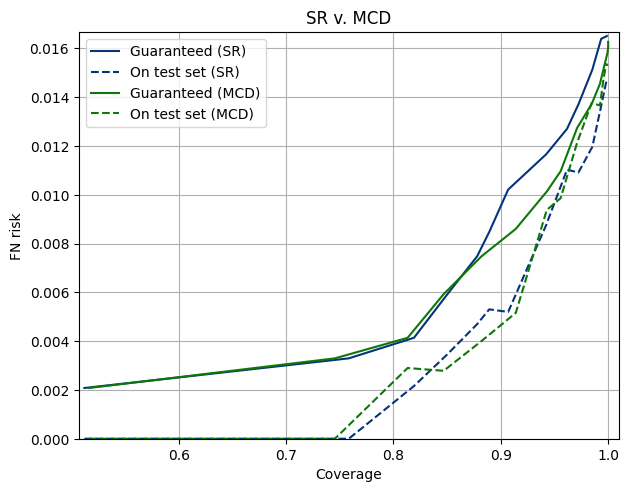

In [151]:
metric_plots(all_results, metric='FN risk', 
             lines_list=lines_list_2,
             xlim=[0.99*min(min(results_SR.test_coverage),min(results_MCD.test_coverage)),
                   1.01*max(max(results_MCD.test_coverage),max(results_SR.test_coverage))], 
             ylim=[0.99*min(min(results_MCD.test_metric), min(results_SR.test_metric)), 
                   1.01*max(max(results_MCD.metric_bound),max(results_SR.metric_bound))],
             title='SR v. MCD')

## <font color = 'orange'> __2. Conditional metrics__

### <font color = 'orange'> 2.1. __FPR__

In [152]:
metric_targets = np.linspace(0.001,0.2,num=num_targets)

In [153]:
results_SR = sgp_at_targets(train_set_SR, test_set_SR,
                            delta=delta, metric_targets=metric_targets, 
                            metric='FPR', mode='greedy', steps=greedy_search_steps_num)
results_MCD = sgp_at_targets(train_set_MCD, test_set_MCD,
                             delta=delta, metric_targets=metric_targets,
                             metric='FPR', mode='greedy', steps=greedy_search_steps_num)
all_results = {'SR': results_SR,
               'MCD': results_MCD}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

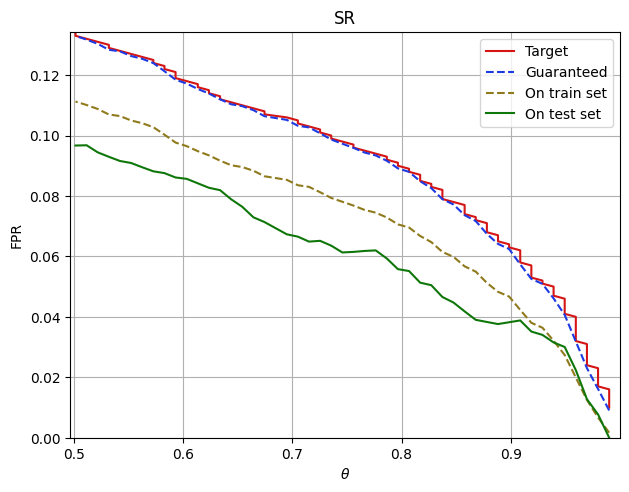

In [154]:
metric_plots(all_results, metric='FPR', 
             lines_list=lines_list_1_SR,
             xlim=[0.99*min(results_SR.theta_star),1.01*max(results_SR.theta_star)], 
             ylim=[0.99*min(results_SR.test_metric), 1.01*max(results_SR.metric_bound)],
             title='SR')

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

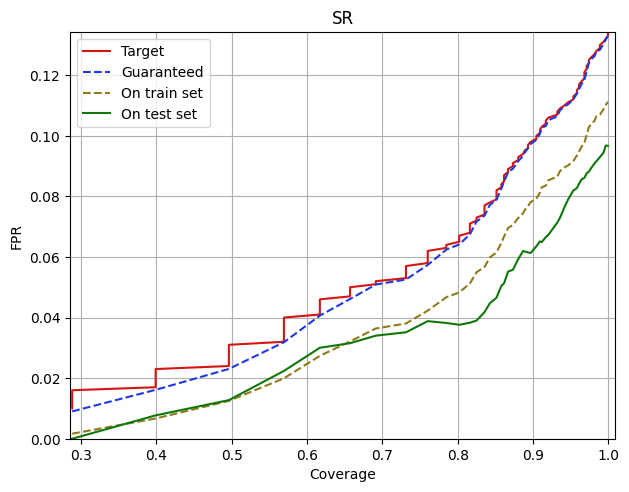

In [155]:
metric_plots(all_results, metric='FPR', 
             lines_list=lines_list_2_SR,
             xlim=[0.99*min(results_SR.test_coverage),1.01*max(results_SR.test_coverage)], 
             ylim=[0.99*min(results_SR.test_metric), 1.01*max(results_SR.metric_bound)],
             title='SR')

Curves w.r.t. $\theta$, using Monte Carlo Dropout (MCD) minus variance as confidence function

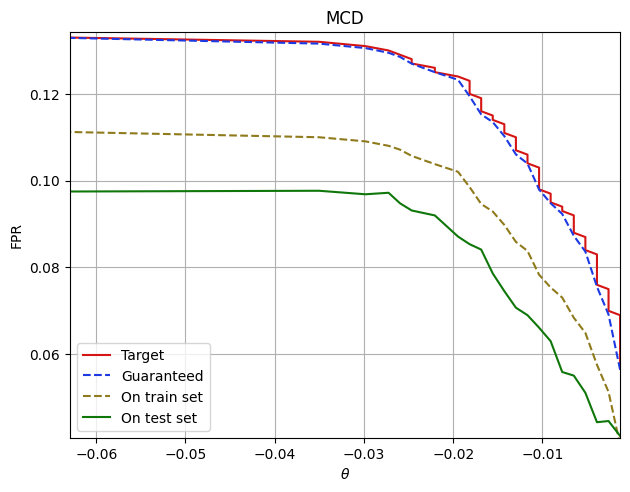

In [156]:
metric_plots(all_results, metric='FPR', 
             lines_list=lines_list_1_MCD,
             xlim=[0.99*min(results_MCD.theta_star),1.01*max(results_MCD.theta_star)], 
             ylim=[0.99*min(results_MCD.test_metric), 1.01*max(results_MCD.metric_bound)],
             title='MCD')

Curves w.r.t. coverage, using Monte Carlo Dropout (MCD) minus variance as confidence function

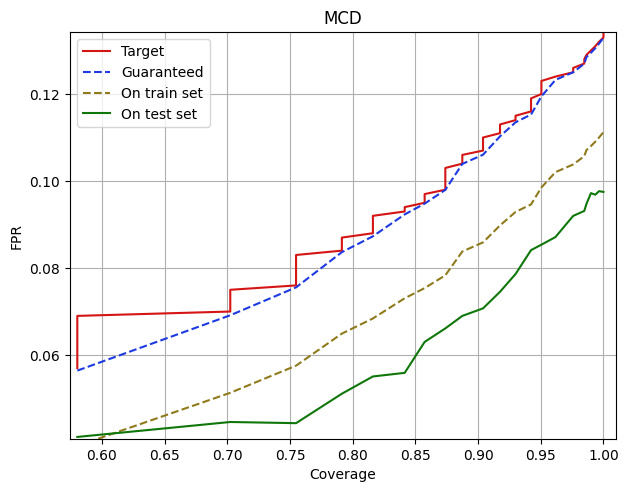

In [157]:
metric_plots(all_results, metric='FPR', 
             lines_list=lines_list_2_MCD,
             xlim=[0.99*min(results_MCD.test_coverage),1.01*max(results_MCD.test_coverage)], 
             ylim=[0.99*min(results_MCD.test_metric), 1.01*max(results_MCD.metric_bound)],
             title='MCD')

Bounds and test set estimates w.r.t. coverage, SR v. MCD 

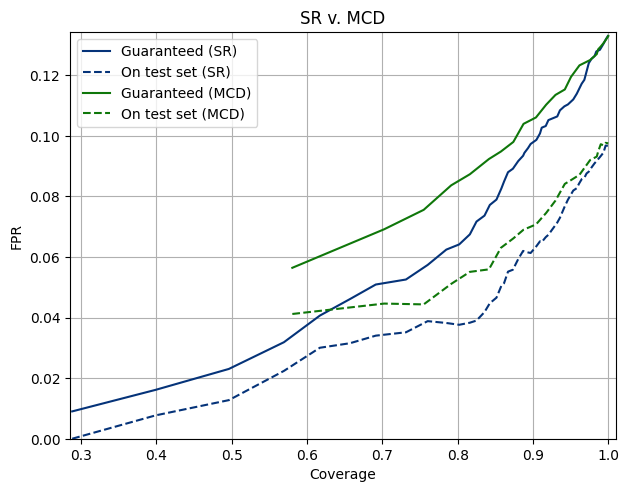

In [158]:
metric_plots(all_results, metric='FPR', 
             lines_list=lines_list_2,
             xlim=[0.99*min(min(results_SR.test_coverage),min(results_MCD.test_coverage)),
                   1.01*max(max(results_MCD.test_coverage),max(results_SR.test_coverage))], 
             ylim=[0.99*min(min(results_MCD.test_metric), min(results_SR.test_metric)), 
                   1.01*max(max(results_MCD.metric_bound),max(results_SR.metric_bound))],
             title='SR v. MCD')

### <font color = 'orange'> 2.2. __FNR__

In [159]:
metric_targets = np.linspace(0.001,0.05,num=num_targets)

In [160]:
results_SR = sgp_at_targets(train_set_SR, test_set_SR,
                            delta=delta, metric_targets=metric_targets, 
                            metric='FNR', mode='greedy', steps=greedy_search_steps_num)
results_MCD = sgp_at_targets(train_set_MCD, test_set_MCD,
                             delta=delta, metric_targets=metric_targets,
                             metric='FNR', mode='greedy', steps=greedy_search_steps_num)
all_results = {'SR': results_SR,
               'MCD': results_MCD}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

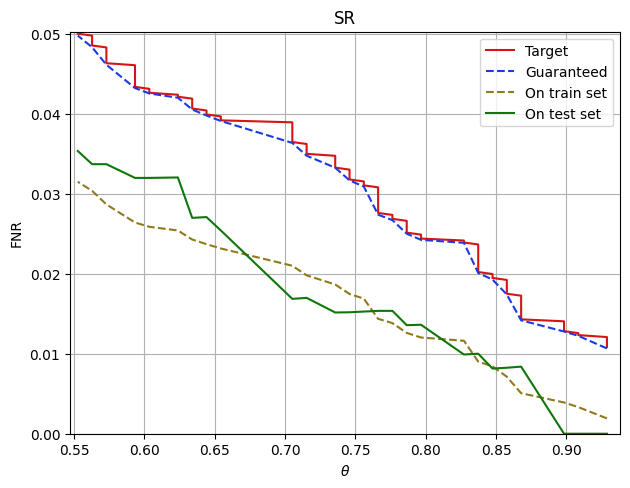

In [161]:
metric_plots(all_results, metric='FNR', 
             lines_list=lines_list_1_SR,
             xlim=[0.99*min(results_SR.theta_star),1.01*max(results_SR.theta_star)], 
             ylim=[0.99*min(results_SR.test_metric), 1.01*max(results_SR.metric_bound)],
             title='SR')

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

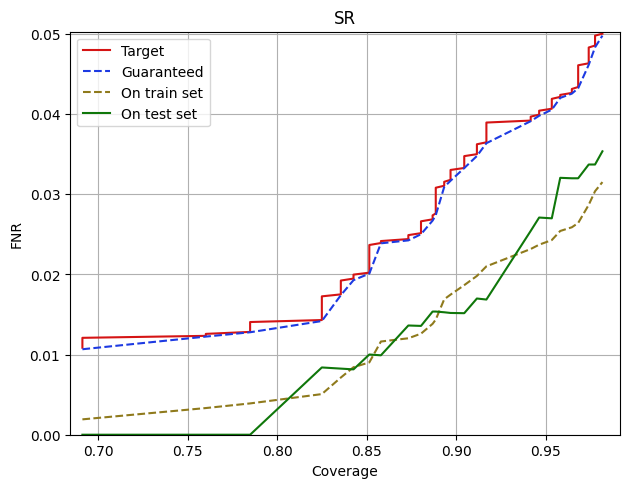

In [162]:
metric_plots(all_results, metric='FNR', 
             lines_list=lines_list_2_SR,
             xlim=[0.99*min(results_SR.test_coverage),1.01*max(results_SR.test_coverage)], 
             ylim=[0.99*min(results_SR.test_metric), 1.01*max(results_SR.metric_bound)],
             title='SR')

Curves w.r.t. $\theta$, using Monte Carlo Dropout (MCD) minus variance as confidence function

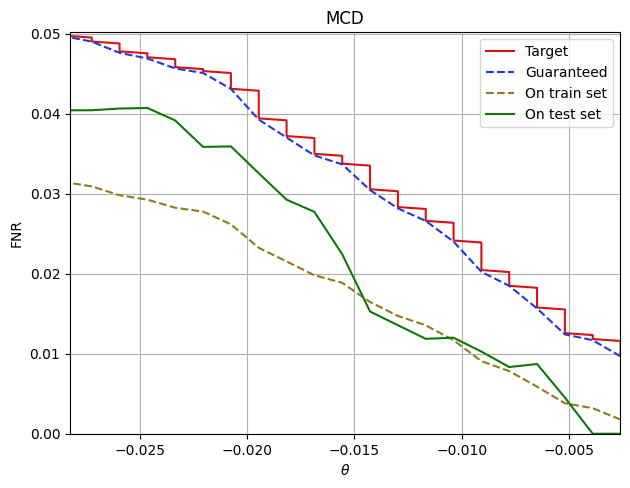

In [163]:
metric_plots(all_results, metric='FNR', 
             lines_list=lines_list_1_MCD,
             xlim=[0.99*min(results_MCD.theta_star),1.01*max(results_MCD.theta_star)], 
             ylim=[0.99*min(results_MCD.test_metric), 1.01*max(results_MCD.metric_bound)],
             title='MCD')

Curves w.r.t. coverage, using Monte Carlo Dropout (MCD) minus variance as confidence function

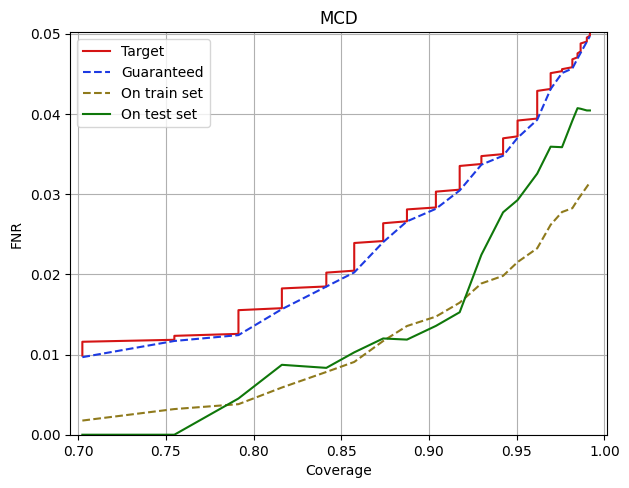

In [164]:
metric_plots(all_results, metric='FNR', 
             lines_list=lines_list_2_MCD,
             xlim=[0.99*min(results_MCD.test_coverage),1.01*max(results_MCD.test_coverage)], 
             ylim=[0.99*min(results_MCD.test_metric), 1.01*max(results_MCD.metric_bound)],
             title='MCD')

Bounds and test set estimates w.r.t. coverage, SR v. MCD 

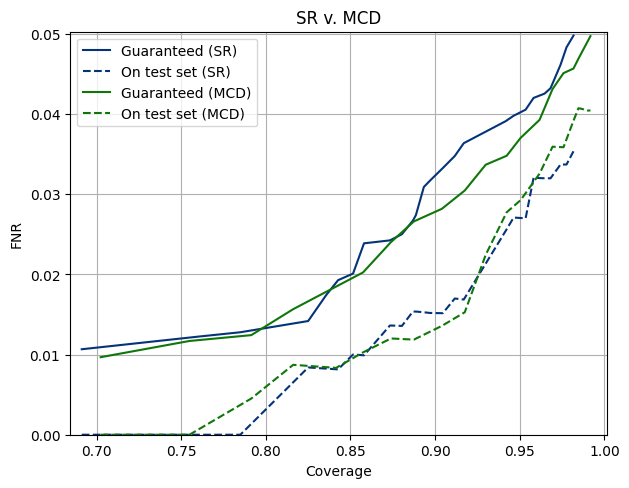

In [165]:
metric_plots(all_results, metric='FNR', 
             lines_list=lines_list_2,
             xlim=[0.99*min(min(results_SR.test_coverage),min(results_MCD.test_coverage)),
                   1.01*max(max(results_MCD.test_coverage),max(results_SR.test_coverage))], 
             ylim=[0.99*min(min(results_MCD.test_metric), min(results_SR.test_metric)), 
                   1.01*max(max(results_MCD.metric_bound),max(results_SR.metric_bound))],
             title='SR v. MCD')

### <font color = 'orange'> 2.3. __PPV__

In [166]:
metric_targets = np.linspace(0.65,0.99,num=num_targets)

In [167]:
results_SR = sgp_at_targets(train_set_SR, test_set_SR,
                            delta=delta, metric_targets=metric_targets, 
                            metric='PPV', mode='greedy', steps=greedy_search_steps_num)
results_MCD = sgp_at_targets(train_set_MCD, test_set_MCD,
                             delta=delta, metric_targets=metric_targets,
                             metric='PPV', mode='greedy', steps=greedy_search_steps_num)
all_results = {'SR': results_SR,
               'MCD': results_MCD}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

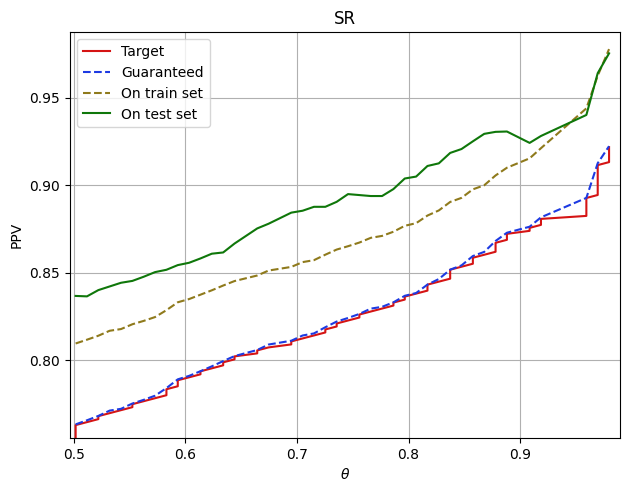

In [168]:
metric_plots(all_results, metric='PPV', 
             lines_list=lines_list_1_SR,
             xlim=[0.99*min(results_SR.theta_star),1.01*max(results_SR.theta_star)], 
             ylim=[0.99*min(results_SR.metric_bound), 
                   min(1,1.01*max(max(results_SR.test_metric),max(results_SR.train_metric)))],
             title='SR')

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

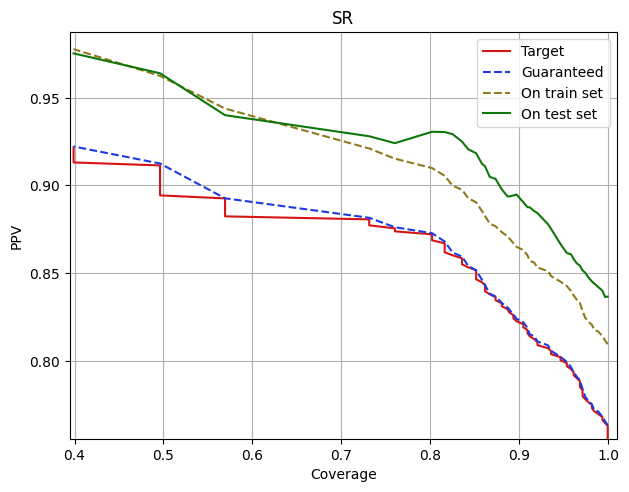

In [169]:
metric_plots(all_results, metric='PPV', 
             lines_list=lines_list_2_SR,
             xlim=[0.99*min(results_SR.test_coverage),1.01*max(results_SR.test_coverage)], 
             ylim=[0.99*min(results_SR.metric_bound), 
                   min(1,1.01*max(max(results_SR.test_metric),max(results_SR.train_metric)))],
             title='SR')

Curves w.r.t. $\theta$, using Monte Carlo Dropout (MCD) minus variance as confidence function

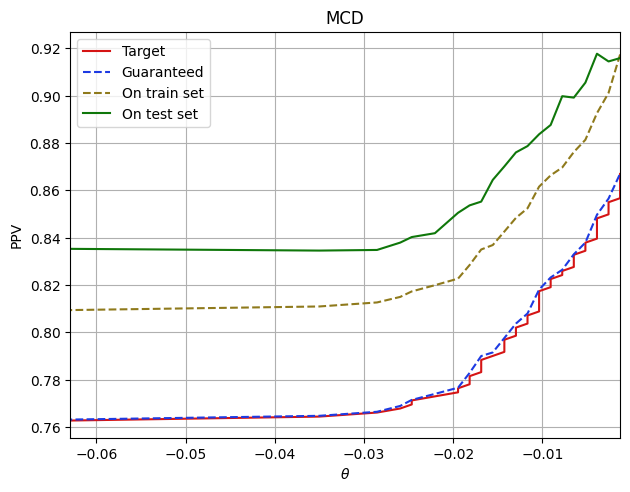

In [170]:
metric_plots(all_results, metric='PPV', 
             lines_list=lines_list_1_MCD,
             xlim=[0.99*min(results_MCD.theta_star),1.01*max(results_MCD.theta_star)], 
             ylim=[0.99*min(results_MCD.metric_bound), 
                   min(1,1.01*max(max(results_MCD.test_metric),max(results_MCD.train_metric)))],
             title='MCD')

Curves w.r.t. coverage, using Monte Carlo Dropout (MCD) minus variance as confidence function

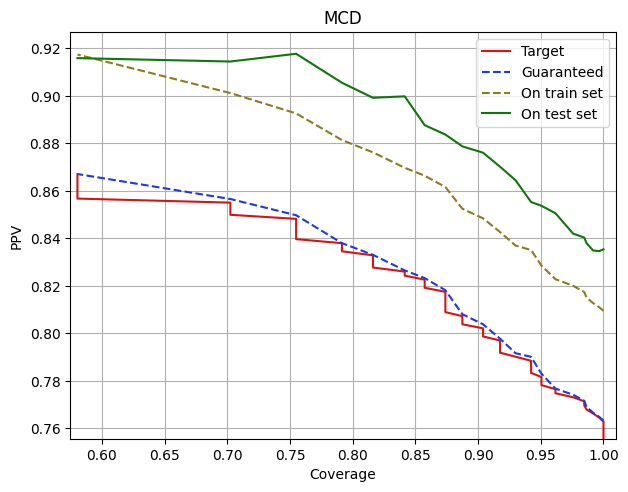

In [171]:
metric_plots(all_results, metric='PPV', 
             lines_list=lines_list_2_MCD,
             xlim=[0.99*min(results_MCD.test_coverage),1.01*max(results_MCD.test_coverage)], 
             ylim=[0.99*min(results_MCD.metric_bound), 
                   min(1,1.01*max(max(results_MCD.test_metric),max(results_MCD.train_metric)))],
             title='MCD')

Bounds and test set estimates w.r.t. coverage, SR v. MCD 

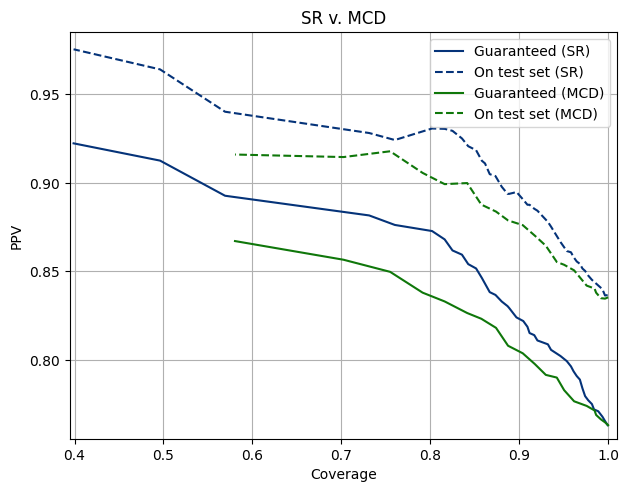

In [172]:
metric_plots(all_results, metric='PPV', 
             lines_list=lines_list_2,
             xlim=[0.99*min(min(results_SR.test_coverage),min(results_MCD.test_coverage)),
                   1.01*max(max(results_SR.test_coverage),max(results_MCD.test_coverage))], 
             ylim=[0.99*min(min(results_MCD.metric_bound), min(results_SR.metric_bound)), 
                   1.01*max(max(results_MCD.test_metric),max(results_SR.test_metric))],
             title='SR v. MCD')

### <font color = 'orange'> 2.4. __SE__

In [173]:
metric_targets = np.linspace(0.95,0.999,num=num_targets)

In [174]:
results_SR = sgp_at_targets(train_set_SR, test_set_SR,
                            delta=delta, metric_targets=metric_targets, 
                            metric='SE', mode='greedy', steps=greedy_search_steps_num)
results_MCD = sgp_at_targets(train_set_MCD, test_set_MCD,
                             delta=delta, metric_targets=metric_targets,
                             metric='SE', mode='greedy', steps=greedy_search_steps_num)
all_results = {'SR': results_SR,
               'MCD': results_MCD}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

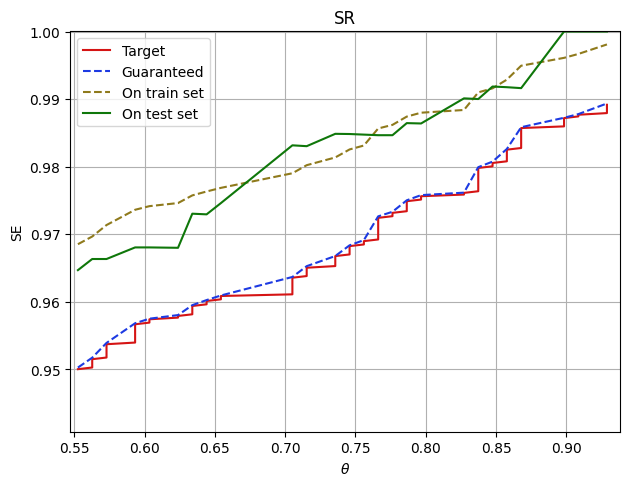

In [175]:
metric_plots(all_results, metric='SE', 
             lines_list=lines_list_1_SR,
             xlim=[0.99*min(results_SR.theta_star),1.01*max(results_SR.theta_star)], 
             ylim=[0.99*min(results_SR.metric_bound), 
                   min(1,1.01*max(max(results_SR.test_metric),max(results_SR.train_metric)))],
             title='SR')

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

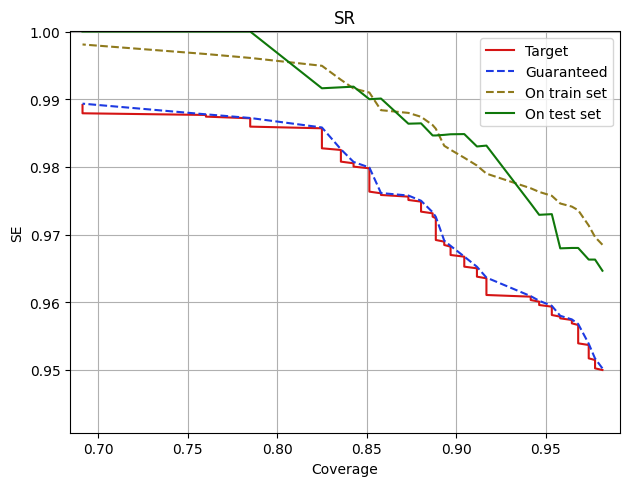

In [176]:
metric_plots(all_results, metric='SE', 
             lines_list=lines_list_2_SR,
             xlim=[0.99*min(results_SR.test_coverage),1.01*max(results_SR.test_coverage)], 
             ylim=[0.99*min(results_SR.metric_bound), 
                   min(1,1.01*max(max(results_SR.test_metric),max(results_SR.train_metric)))],
             title='SR')

Curves w.r.t. $\theta$, using Monte Carlo Dropout (MCD) minus variance as confidence function

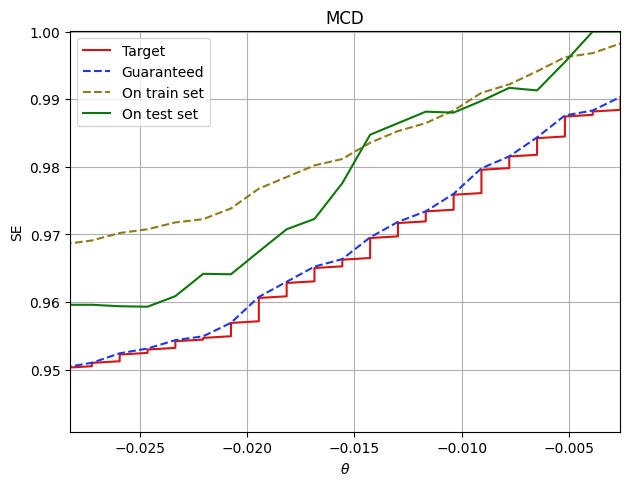

In [177]:
metric_plots(all_results, metric='SE', 
             lines_list=lines_list_1_MCD,
             xlim=[0.99*min(results_MCD.theta_star),1.01*max(results_MCD.theta_star)], 
             ylim=[0.99*min(results_MCD.metric_bound), 
                   min(1,1.01*max(max(results_MCD.test_metric),max(results_MCD.train_metric)))],
             title='MCD')

Curves w.r.t. coverage, using Monte Carlo Dropout (MCD) minus variance as confidence function

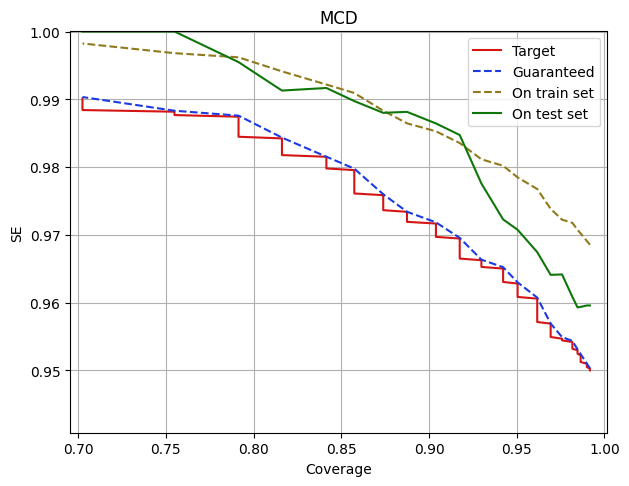

In [178]:
metric_plots(all_results, metric='SE', 
             lines_list=lines_list_2_MCD,
             xlim=[0.99*min(results_MCD.test_coverage),1.01*max(results_MCD.test_coverage)], 
             ylim=[0.99*min(results_MCD.metric_bound), 
                   min(1,1.01*max(max(results_MCD.test_metric),max(results_MCD.train_metric)))],
             title='MCD')

Bounds and test set estimates w.r.t. coverage, SR v. MCD 

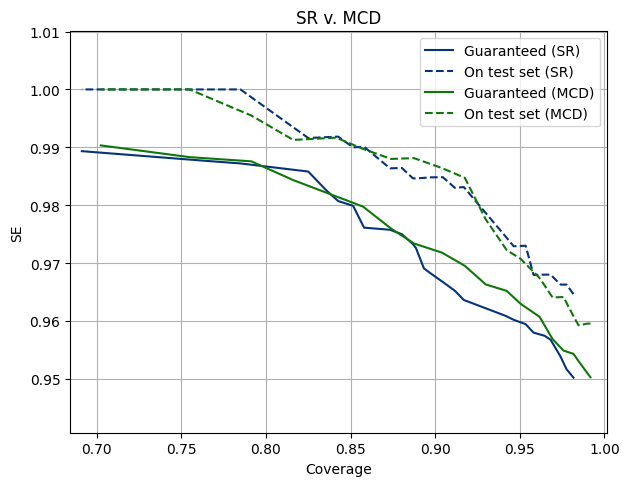

In [179]:
metric_plots(all_results, metric='SE', 
             lines_list=lines_list_2,
             xlim=[0.99*min(min(results_SR.test_coverage),min(results_MCD.test_coverage)),
                   1.01*max(max(results_SR.test_coverage),max(results_MCD.test_coverage))], 
             ylim=[0.99*min(min(results_MCD.metric_bound), min(results_SR.metric_bound)), 
                   1.01*max(max(results_MCD.test_metric),max(results_SR.test_metric))],
             title='SR v. MCD')

### <font color = 'orange'> 2.5. __SP__

In [180]:
metric_targets = np.linspace(0.8,0.999,num=num_targets)

In [181]:
results_SR = sgp_at_targets(train_set_SR, test_set_SR,
                            delta=delta, metric_targets=metric_targets, 
                            metric='SP', mode='greedy', steps=greedy_search_steps_num)
results_MCD = sgp_at_targets(train_set_MCD, test_set_MCD,
                             delta=delta, metric_targets=metric_targets,
                             metric='SP', mode='greedy', steps=greedy_search_steps_num)
all_results = {'SR': results_SR,
               'MCD': results_MCD}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

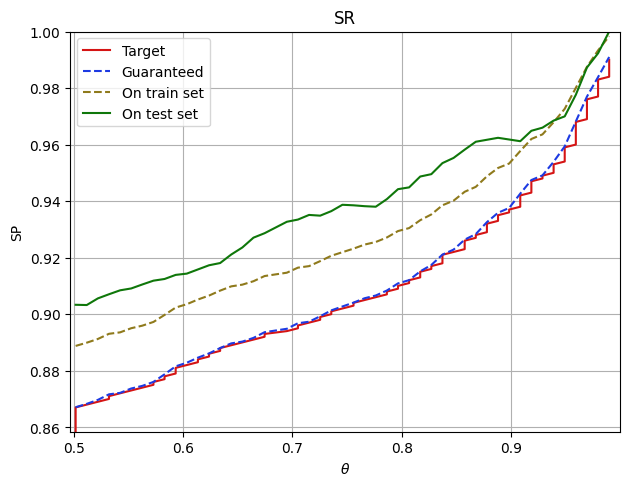

In [182]:
metric_plots(all_results, metric='SP', 
             lines_list=lines_list_1_SR,
             xlim=[0.99*min(results_SR.theta_star),1.01*max(results_SR.theta_star)], 
             ylim=[0.99*min(results_SR.metric_bound), 
                   min(1,1.01*max(max(results_SR.test_metric),max(results_SR.train_metric)))],
             title='SR')

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

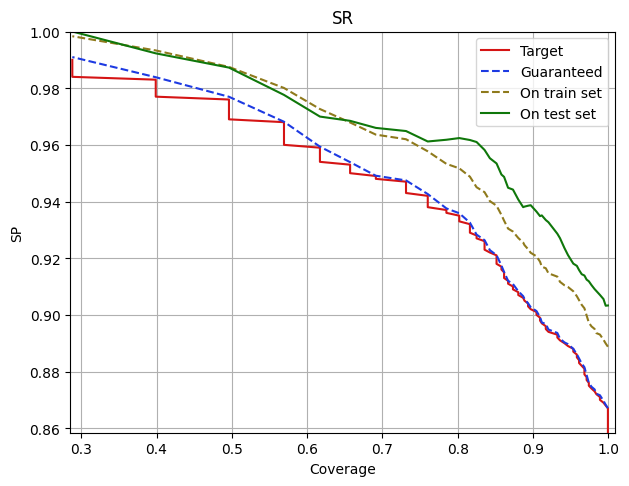

In [183]:
metric_plots(all_results, metric='SP', 
             lines_list=lines_list_2_SR,
             xlim=[0.99*min(results_SR.test_coverage),1.01*max(results_SR.test_coverage)], 
             ylim=[0.99*min(results_SR.metric_bound), 
                   min(1,1.01*max(max(results_SR.test_metric),max(results_SR.train_metric)))],
             title='SR')

Curves w.r.t. $\theta$, using Monte Carlo Dropout (MCD) minus variance as confidence function

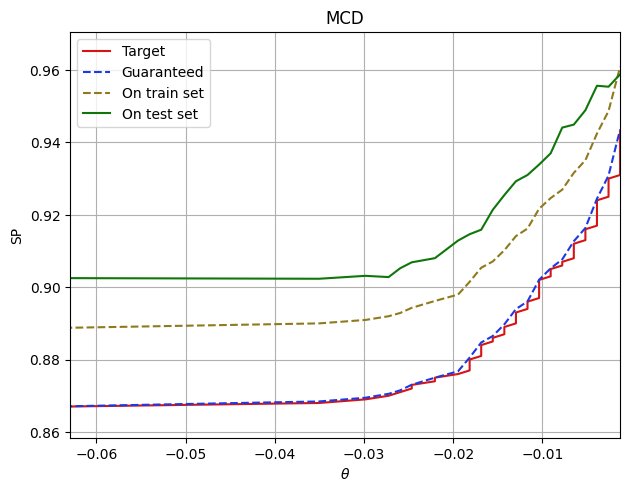

In [184]:
metric_plots(all_results, metric='SP', 
             lines_list=lines_list_1_MCD,
             xlim=[0.99*min(results_MCD.theta_star),1.01*max(results_MCD.theta_star)], 
             ylim=[0.99*min(results_MCD.metric_bound), 
                   min(1,1.01*max(max(results_MCD.test_metric),max(results_MCD.train_metric)))],
             title='MCD')

Curves w.r.t. coverage, using Monte Carlo Dropout (MCD) minus variance as confidence function

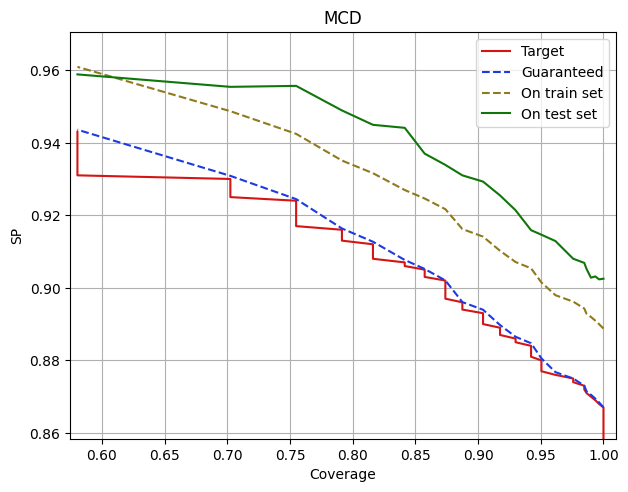

In [185]:
metric_plots(all_results, metric='SP', 
             lines_list=lines_list_2_MCD,
             xlim=[0.99*min(results_MCD.test_coverage),1.01*max(results_MCD.test_coverage)], 
             ylim=[0.99*min(results_MCD.metric_bound), 
                   min(1,1.01*max(max(results_MCD.test_metric),max(results_MCD.train_metric)))],
             title='MCD')

Bounds and test set estimates w.r.t. coverage, SR v. MCD 

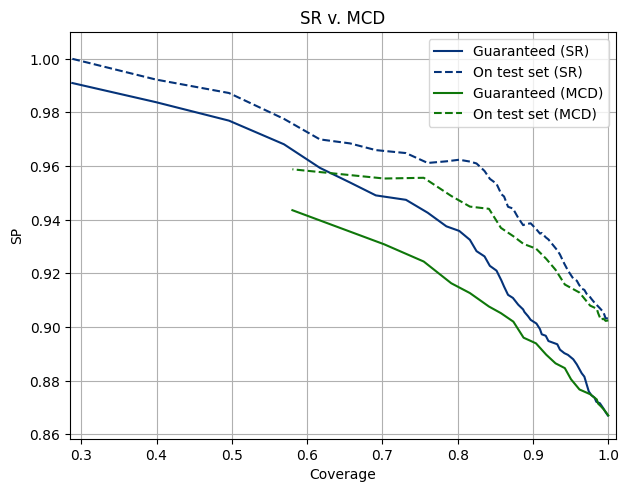

In [186]:
metric_plots(all_results, metric='SP', 
             lines_list=lines_list_2,
             xlim=[0.99*min(min(results_SR.test_coverage),min(results_MCD.test_coverage)),
                   1.01*max(max(results_SR.test_coverage),max(results_MCD.test_coverage))], 
             ylim=[0.99*min(min(results_MCD.metric_bound), min(results_SR.metric_bound)), 
                   1.01*max(max(results_MCD.test_metric),max(results_SR.test_metric))],
             title='SR v. MCD')